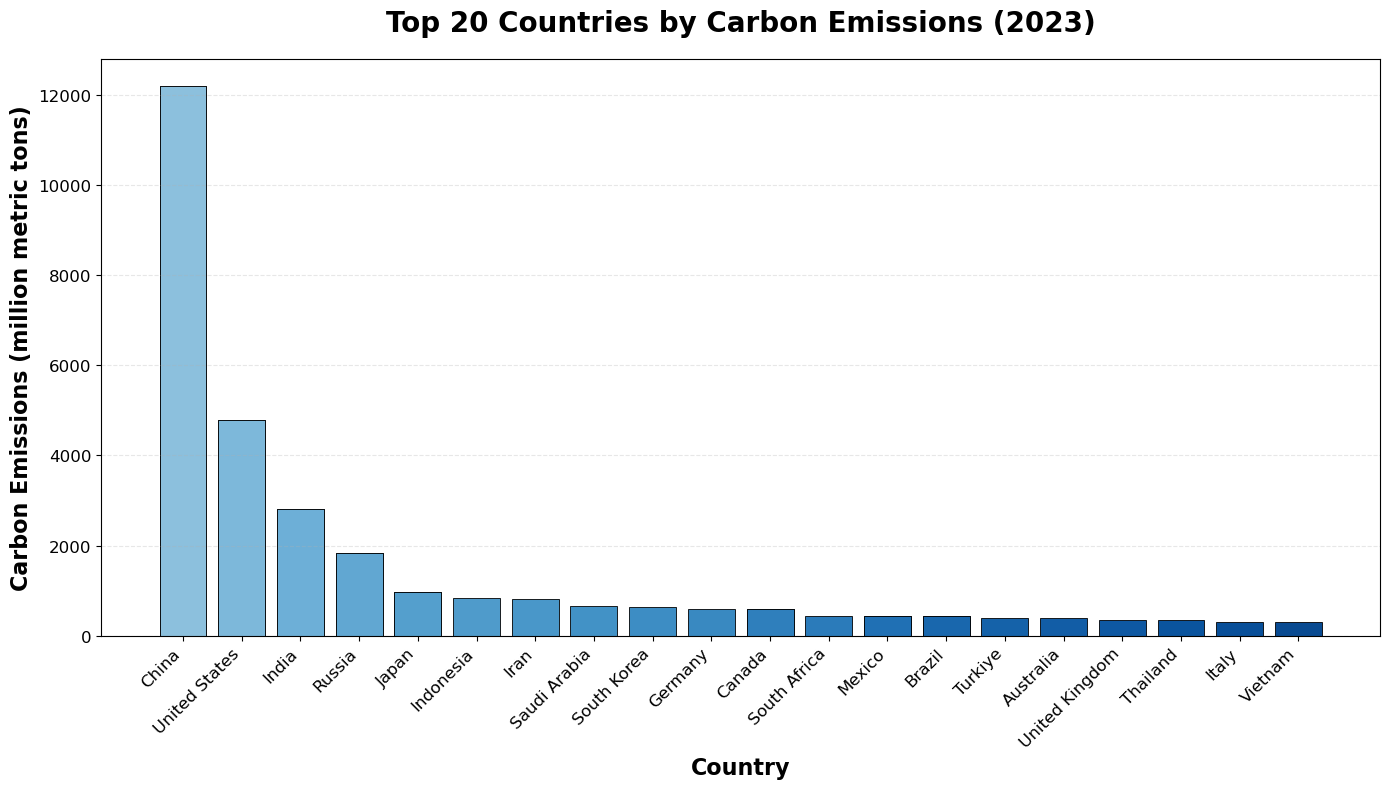

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===================== 1. 固定配置 =====================
CO2_FILE = "co2-emissions-emissions-mmtco2.csv"
TARGET_YEAR = "2023"

# 你指定的 20 个国家（必须画这些）
countries = [
    "China", "United States", "India", "Russia", "Japan",
    "Indonesia", "Iran", "Saudi Arabia", "South Korea", "Germany",
    "Canada", "South Africa", "Mexico", "Brazil", "Turkiye",
    "Australia", "United Kingdom", "Thailand", "Italy", "Vietnam"
]

# ===================== 2. 读取并筛选数据 =====================
df = pd.read_csv(CO2_FILE)

# 提取国家列 + 2023年
df = df[[df.columns[0], TARGET_YEAR]]
df.columns = ["Country", "Emissions"]
df["Emissions"] = pd.to_numeric(df["Emissions"], errors="coerce")

# 只保留你指定的国家
df = df[df["Country"].isin(countries)]

# 从大到小排序
df_sorted = df.sort_values("Emissions", ascending=False)

# 取出画图数据
countries_sorted = df_sorted["Country"].tolist()
emissions_sorted = df_sorted["Emissions"].tolist()

# ===================== 3. 字体风格 =====================
TICK_FONT_SIZE = 14
LABEL_FONT_SIZE = 16
TITLE_FONT_SIZE = 20

# ===================== 4. 绘图 =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.figure(figsize=(14, 8))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(countries_sorted)))
bars = plt.bar(
    countries_sorted, emissions_sorted,
    color=colors, edgecolor='black', linewidth=0.6
)

plt.title('Top 20 Countries by Carbon Emissions (2023)', fontsize=TITLE_FONT_SIZE, weight='bold', pad=20)
plt.xlabel('Country', fontsize=LABEL_FONT_SIZE, weight='bold')
plt.ylabel('Carbon Emissions (million metric tons)', fontsize=LABEL_FONT_SIZE, weight='bold')

plt.xticks(rotation=45, ha='right', fontsize=TICK_FONT_SIZE-2)
plt.yticks(fontsize=TICK_FONT_SIZE-2)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
#plt.savefig('a.png', dpi=300, bbox_inches='tight')
plt.show()

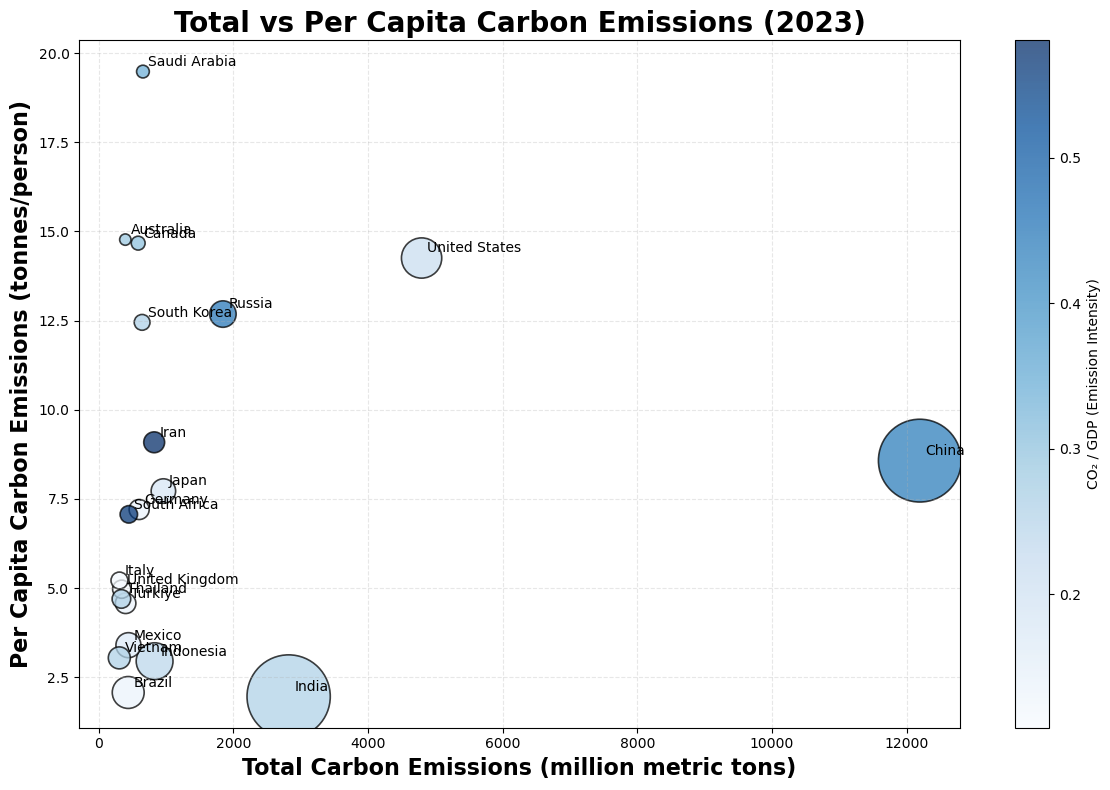

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===================== 【1】文件读取配置 =====================
CO2_FILE    = "co2-emissions-emissions-mmtco2.csv"          
POP_FILE    = "population-population-people-in-thousands.csv"  
GDP_FILE    = "gross-domestic-product-gdp-billion-dollars-at-purchasing-power-parities.csv"
TARGET_YEAR = "2023"  

# ===================== ✅ 把剔除的4个国家放回去（完整版） =====================
countries = [
    "China", "India", "United States", "Russia",  # 之前踢掉的，现在加回来
    "Japan", "Indonesia", "Iran", "Saudi Arabia", "South Korea",
    "Germany", "Canada", "South Africa", "Mexico", "Brazil",
    "Turkiye", "Australia", "United Kingdom", "Thailand", "Italy", "Vietnam"
]

# ===================== 【2】通用读取函数 =====================
def get_value(df, country, year_col):
    mask = df.iloc[:, 0].str.strip() == country
    if mask.any():
        val = df.loc[mask, year_col].iloc[0]
        return float(val) if not pd.isna(val) else 0
    return 0

# ===================== 【3】读取三个文件 =====================
co2_df = pd.read_csv(CO2_FILE)
pop_df = pd.read_csv(POP_FILE)
gdp_df = pd.read_csv(GDP_FILE)

# ===================== 【4】批量提取 2023 年数据 =====================
co2_total = []       
co2_per_capita = []  
population = []      
co2_gdp = []         

for c in countries:
    co2 = get_value(co2_df, c, TARGET_YEAR)
    pop_thousand = get_value(pop_df, c, TARGET_YEAR)
    pop_million = pop_thousand / 1000
    gdp = get_value(gdp_df, c, TARGET_YEAR)
    
    per_cap = (co2 * 1_000_000) / (pop_thousand * 1000) if pop_thousand >0 else 0
    intensity = co2 / gdp if gdp >0 else 0
    
    co2_total.append(co2)
    population.append(pop_million)
    co2_per_capita.append(per_cap)
    co2_gdp.append(intensity)

# ===================== 统一字体风格 =====================
TICK_FONT_SIZE = 14
LABEL_FONT_SIZE = 16
TITLE_FONT_SIZE = 20

# ===================== 绘图 =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.figure(figsize=(12, 8))

sc = plt.scatter(
    co2_total, co2_per_capita,
    s=np.array(population) * 2.5,
    c=co2_gdp,
    cmap="Blues",
    alpha=0.75, edgecolors="black", linewidth=1.2
)

# 国家标签
for i, country in enumerate(countries):
    plt.annotate(
        country,
        (co2_total[i], co2_per_capita[i]),
        xytext=(4, 4), textcoords='offset points', fontsize=10
    )

plt.xlabel('Total Carbon Emissions (million metric tons)', fontsize=LABEL_FONT_SIZE, weight='bold')
plt.ylabel('Per Capita Carbon Emissions (tonnes/person)', fontsize=LABEL_FONT_SIZE, weight='bold')
plt.title('Total vs Per Capita Carbon Emissions (2023)', fontsize=TITLE_FONT_SIZE, weight='bold')

plt.colorbar(sc, label='CO₂ / GDP (Emission Intensity)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
#plt.savefig('a.png', dpi=300, bbox_inches='tight')
plt.show()

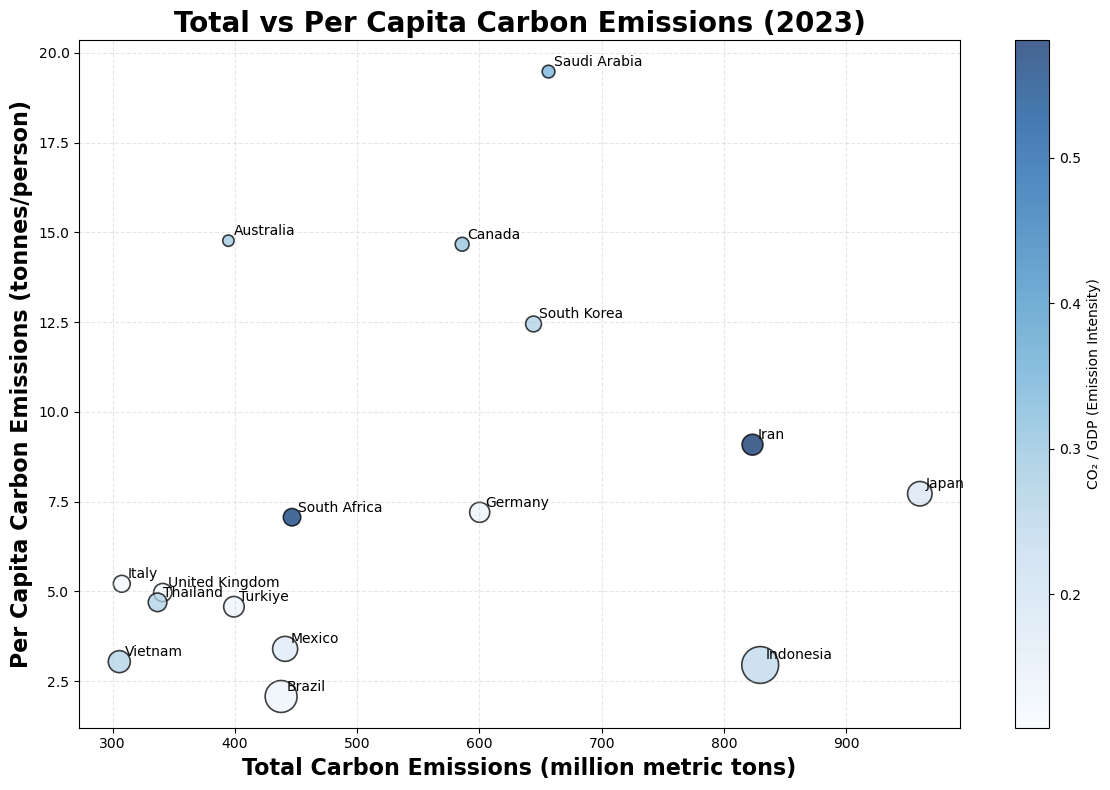

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===================== 【1】文件读取配置（你只需要确保文件名正确） =====================
CO2_FILE    = "co2-emissions-emissions-mmtco2.csv"          # CO2 总排放（百万公吨）
POP_FILE    = "population-population-people-in-thousands.csv"  # 人口（千人）
GDP_FILE    = "gross-domestic-product-gdp-billion-dollars-at-purchasing-power-parities.csv" # GDP（十亿美元）
TARGET_YEAR = "2023"  # 你要画的年份

# 需要画图的国家（剔除中、印、美、俄）
countries = [
    "Japan", "Indonesia", "Iran", "Saudi Arabia", "South Korea",
    "Germany", "Canada", "South Africa", "Mexico", "Brazil",
    "Turkiye", "Australia", "United Kingdom", "Thailand", "Italy", "Vietnam"
]

# ===================== 【2】通用读取函数（自动按国家+年份取数） =====================
def get_value(df, country, year_col):
    """从DataFrame中提取指定国家、指定年份的值"""
    mask = df.iloc[:, 0].str.strip() == country
    if mask.any():
        val = df.loc[mask, year_col].iloc[0]
        return float(val) if not pd.isna(val) else 0
    return 0

# ===================== 【3】读取三个文件 =====================
# 1. 读取 CO2 总排放
co2_df = pd.read_csv(CO2_FILE)
# 2. 读取人口
pop_df = pd.read_csv(POP_FILE)
# 3. 读取 GDP
gdp_df = pd.read_csv(GDP_FILE)

# ===================== 【4】批量提取 2023 年数据 =====================
co2_total = []       # X轴：总排放（百万公吨）
co2_per_capita = []  # Y轴：人均排放（吨/人）
population = []      # 气泡大小：人口（百万）
co2_gdp = []         # 颜色：排放强度（CO2/GDP）

for c in countries:
    # 总排放 (Million metric tons)
    co2 = get_value(co2_df, c, TARGET_YEAR)
    # 人口 (千人 → 转成 百万人)
    pop_thousand = get_value(pop_df, c, TARGET_YEAR)
    pop_million = pop_thousand / 1000
    # GDP (Billion $)
    gdp = get_value(gdp_df, c, TARGET_YEAR)
    
    # 人均排放 = 总吨数 / 总人数
    # co2（百万公吨）×1e6 = 公吨； pop_thousand ×1000 = 人
    per_cap = (co2 * 1_000_000) / (pop_thousand * 1_000) if pop_thousand >0 else 0
    # 排放强度 = CO2 / GDP
    intensity = co2 / gdp if gdp >0 else 0
    
    co2_total.append(co2)
    population.append(pop_million)
    co2_per_capita.append(per_cap)
    co2_gdp.append(intensity)

# ===================== 【5】统一字体大小（和你之前风格一致） =====================
TICK_FONT_SIZE = 14
LABEL_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
LEGEND_FONT_SIZE = 15

# ===================== 【6】绘制气泡图 =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.figure(figsize=(12, 8))

sc = plt.scatter(
    co2_total, co2_per_capita,
    s=np.array(population) * 2.5,  # 气泡大小 = 人口
    c=co2_gdp,                    # 颜色 = 排放强度
    cmap="Blues",
    alpha=0.75, edgecolors="black", linewidth=1.2
)

# 国家标注
for i, country in enumerate(countries):
    plt.annotate(
        country,
        (co2_total[i], co2_per_capita[i]),
        xytext=(4, 4), textcoords='offset points', fontsize=10
    )

# 坐标轴（单位完全正确！）
plt.xlabel('Total Carbon Emissions (million metric tons)', fontsize=LABEL_FONT_SIZE, weight='bold')
plt.ylabel('Per Capita Carbon Emissions (tonnes/person)', fontsize=LABEL_FONT_SIZE, weight='bold')
plt.title('Total vs Per Capita Carbon Emissions (2023)', fontsize=TITLE_FONT_SIZE, weight='bold')

# 颜色条
plt.colorbar(sc, label='CO₂ / GDP (Emission Intensity)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
#plt.savefig('a.png', dpi=300, bbox_inches='tight')
plt.show()

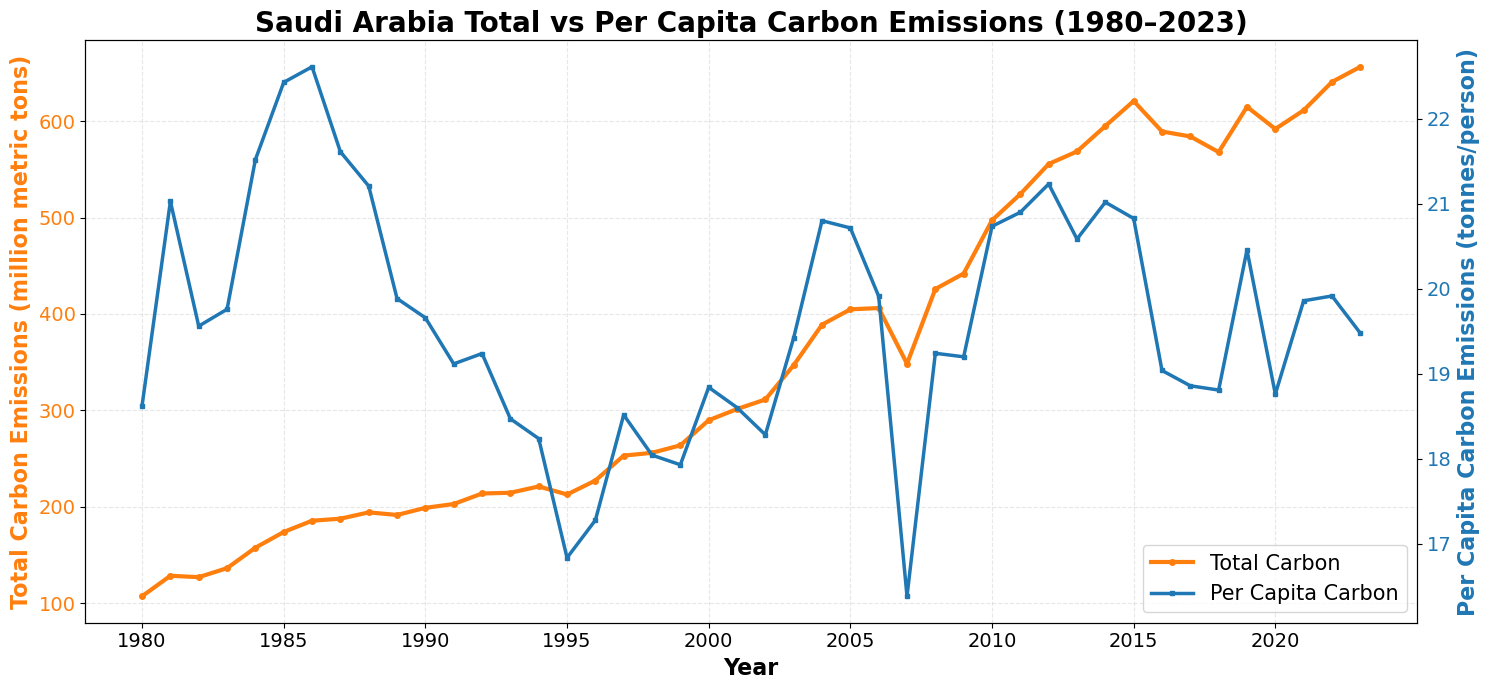

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===================== 1. 读取数据 =====================
years = np.arange(1980, 2024)
year_cols = years.astype(str).tolist()

# CO2 单位：百万吨 MMT
co2_df = pd.read_csv('co2-emissions-emissions-mmtco2.csv')
saudi_co2 = co2_df[co2_df.iloc[:, 0] == 'Saudi Arabia'][year_cols].iloc[0]
co2_saudi = saudi_co2.values.astype(float)

# 人口单位：千人
pop_df = pd.read_csv('population-population-people-in-thousands.csv')
saudi_pop = pop_df[pop_df.iloc[:, 0] == 'Saudi Arabia'][year_cols].iloc[0]
population = saudi_pop.values.astype(float)

# ===================== ✅ 正确计算：人均 CO2（吨/人） =====================
co2_per_cap = co2_saudi * 1000 / population

# ===================== 字体 =====================
TICK_FONT_SIZE = 14
LABEL_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
LEGEND_FONT_SIZE = 15

# ===================== 绘图 =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
fig, ax1 = plt.subplots(figsize=(15, 7))

# 左Y：总排放（百万吨）
color1 = '#ff7f0e'
ax1.set_xlabel('Year', fontsize=LABEL_FONT_SIZE, weight='bold')
ax1.set_ylabel('Total Carbon Emissions (million metric tons)', color=color1, fontsize=LABEL_FONT_SIZE, weight='bold')
ax1.plot(years, co2_saudi, color=color1, linewidth=3, marker='o', markersize=4, label='Total Carbon')
ax1.tick_params(axis='y', labelcolor=color1, labelsize=TICK_FONT_SIZE)
ax1.grid(alpha=0.3, linestyle='--')

# 右Y：✅ 正确单位：吨/人
ax2 = ax1.twinx()
color2 = '#1f77b4'
ax2.set_ylabel('Per Capita Carbon Emissions (tonnes/person)', color=color2, fontsize=LABEL_FONT_SIZE, weight='bold')
ax2.plot(years, co2_per_cap, color=color2, linewidth=2.5, marker='s', markersize=3.5, label='Per Capita Carbon')
ax2.tick_params(axis='y', labelcolor=color2, labelsize=TICK_FONT_SIZE)

# 标题
plt.title('Saudi Arabia Total vs Per Capita Carbon Emissions (1980–2023)', fontsize=TITLE_FONT_SIZE, weight='bold')
ax1.set_xticks(np.arange(1980, 2024, 5))
ax1.tick_params(axis='x', labelsize=TICK_FONT_SIZE)
ax1.set_xlim(1978, 2025)

# 图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=LEGEND_FONT_SIZE)

fig.tight_layout()
#plt.savefig('a.png', dpi=300, bbox_inches='tight')
plt.show()

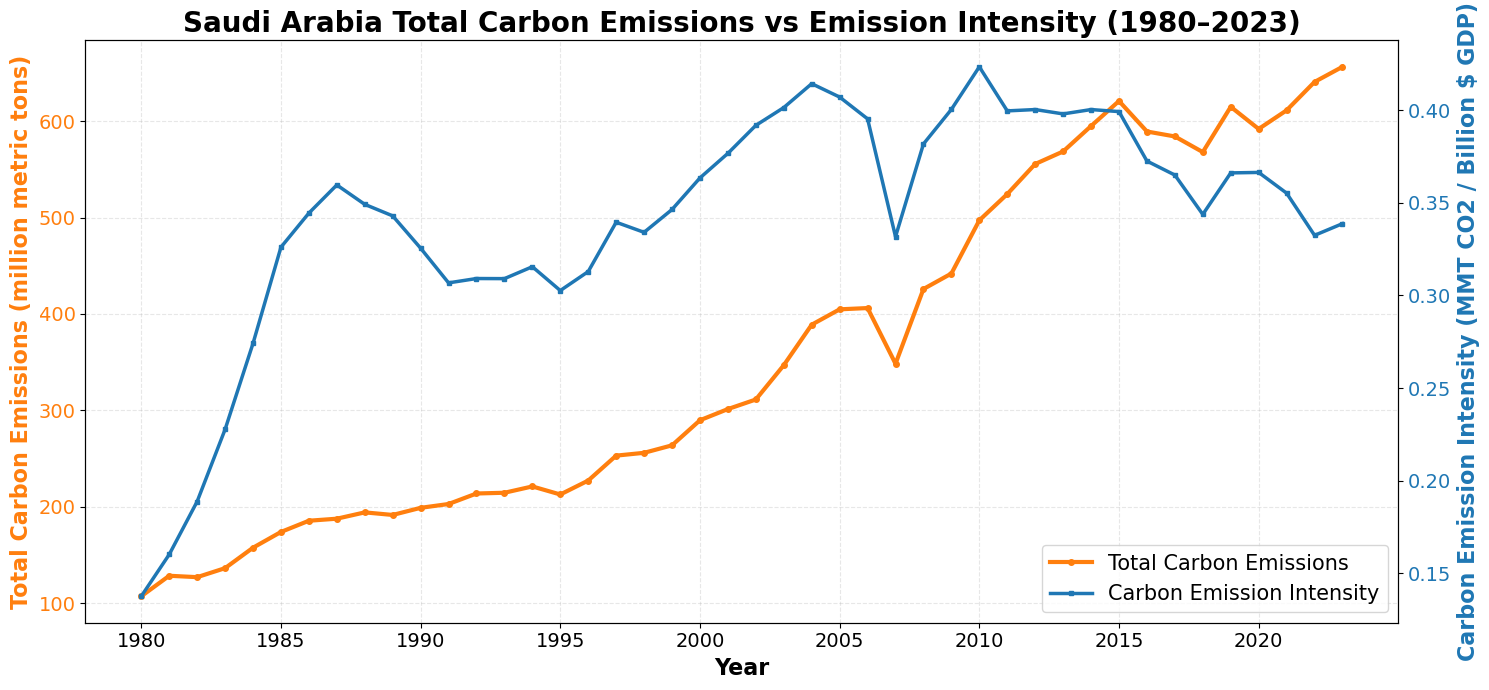

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===================== 1. 读取数据 =====================
years = np.arange(1980, 2024)
year_cols = years.astype(str).tolist()

# CO2 单位：百万吨 MMT
co2_df = pd.read_csv('co2-emissions-emissions-mmtco2.csv')
saudi_co2 = co2_df[co2_df.iloc[:, 0] == 'Saudi Arabia'][year_cols].iloc[0]
co2_saudi = saudi_co2.values.astype(float)

# GDP 单位：十亿美元 (Billion $)
gdp_df = pd.read_csv('gross-domestic-product-gdp-billion-dollars-at-purchasing-power-parities.csv')
saudi_gdp = gdp_df[gdp_df.iloc[:, 0] == 'Saudi Arabia'][year_cols].iloc[0]
gdp_saudi = saudi_gdp.values.astype(float)

# ===================== ✅ 正确计算：碳强度 CO2/GDP =====================
# 强度 = 总排放(百万吨) / GDP(十亿美元)
co2_intensity = co2_saudi / gdp_saudi

# ===================== 字体 =====================
TICK_FONT_SIZE = 14
LABEL_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
LEGEND_FONT_SIZE = 15

# ===================== 绘图 =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
fig, ax1 = plt.subplots(figsize=(15, 7))

# 左Y：总排放（百万吨）
color1 = '#ff7f0e'
ax1.set_xlabel('Year', fontsize=LABEL_FONT_SIZE, weight='bold')
ax1.set_ylabel('Total Carbon Emissions (million metric tons)', color=color1, fontsize=LABEL_FONT_SIZE, weight='bold')
ax1.plot(years, co2_saudi, color=color1, linewidth=3, marker='o', markersize=4, label='Total Carbon Emissions')
ax1.tick_params(axis='y', labelcolor=color1, labelsize=TICK_FONT_SIZE)
ax1.grid(alpha=0.3, linestyle='--')

# 右Y：✅ 碳强度 CO2/GDP
ax2 = ax1.twinx()
color2 = '#1f77b4'
ax2.set_ylabel('Carbon Emission Intensity (MMT CO2 / Billion $ GDP)', color=color2, fontsize=LABEL_FONT_SIZE, weight='bold')
ax2.plot(years, co2_intensity, color=color2, linewidth=2.5, marker='s', markersize=3.5, label='Carbon Emission Intensity')
ax2.tick_params(axis='y', labelcolor=color2, labelsize=TICK_FONT_SIZE)

# 标题
plt.title('Saudi Arabia Total Carbon Emissions vs Emission Intensity (1980–2023)', fontsize=TITLE_FONT_SIZE, weight='bold')
ax1.set_xticks(np.arange(1980, 2024, 5))
ax1.tick_params(axis='x', labelsize=TICK_FONT_SIZE)
ax1.set_xlim(1978, 2025)

# 图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=LEGEND_FONT_SIZE)

fig.tight_layout()
plt.savefig('saudi_co2_intensity.png', dpi=300, bbox_inches='tight')
plt.show()

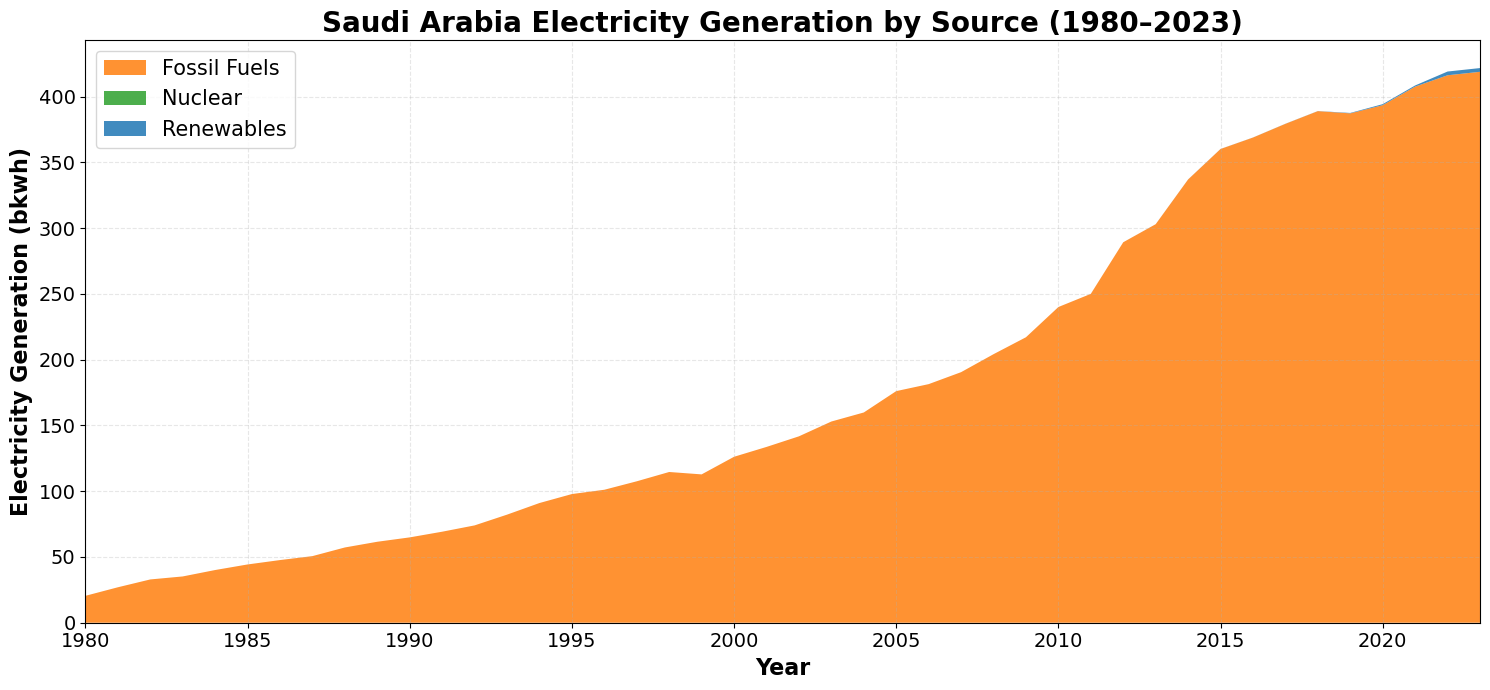

In [39]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 自动搜索文件
csv_files = glob.glob("**/*generation*bkwh.csv", recursive=True)
file_map = {os.path.basename(f): f for f in csv_files}

# 年份 1980–2023
years = np.arange(1980, 2024)
year_strs = years.astype(str)

# 读取沙特阿拉伯数据函数
def get_saudi(filename):
    df = pd.read_csv(file_map[filename], na_values=["NA", "N/A", "nan", ""])
    saudi = df[df["Country"].str.strip() == "Saudi Arabia"].iloc[0]
    return saudi[year_strs].fillna(0).astype(float).values

# 读取三大类数据
fossil = get_saudi("fossil-fuels-generation-bkwh.csv")
nuclear = get_saudi("nuclear-generation-bkwh.csv")
renewables = get_saudi("renewables-generation-bkwh.csv")

# ===================== 可调节参数（在这里改大小） =====================
TICK_FONT_SIZE = 14      # X/Y 轴刻度数字大小（修改这里）
LABEL_FONT_SIZE = 16     # X/Y 轴标签大小
TITLE_FONT_SIZE = 20     # 标题大小
LEGEND_FONT_SIZE = 15    # 图例大小

# ===================== 绘图（完全匹配你的风格） =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
fig, ax = plt.subplots(figsize=(15, 7))

# 堆叠面积图（专业配色 + 干净风格）
ax.stackplot(
    years,
    fossil,
    nuclear,
    renewables,
    labels=["Fossil Fuels", "Nuclear", "Renewables"],
    colors=["#ff7f0e", "#2ca02c", "#1f77b4"],
    alpha=0.85
)

# 轴标签
ax.set_xlabel('Year', fontsize=LABEL_FONT_SIZE, weight='bold')
ax.set_ylabel('Electricity Generation (bkwh)', fontsize=LABEL_FONT_SIZE, weight='bold')

# 标题
plt.title('Saudi Arabia Electricity Generation by Source (1980–2023)', fontsize=TITLE_FONT_SIZE, weight='bold')

# 坐标轴刻度 + 网格（关键：设置刻度数字大小）
ax.set_xticks(np.arange(1980, 2024, 5))
ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)  # 控制 X/Y 数字大小
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=LEGEND_FONT_SIZE)
ax.set_xlim(1980, 2023)
fig.tight_layout()
#plt.savefig('a.png', dpi=300, bbox_inches='tight')
plt.show()

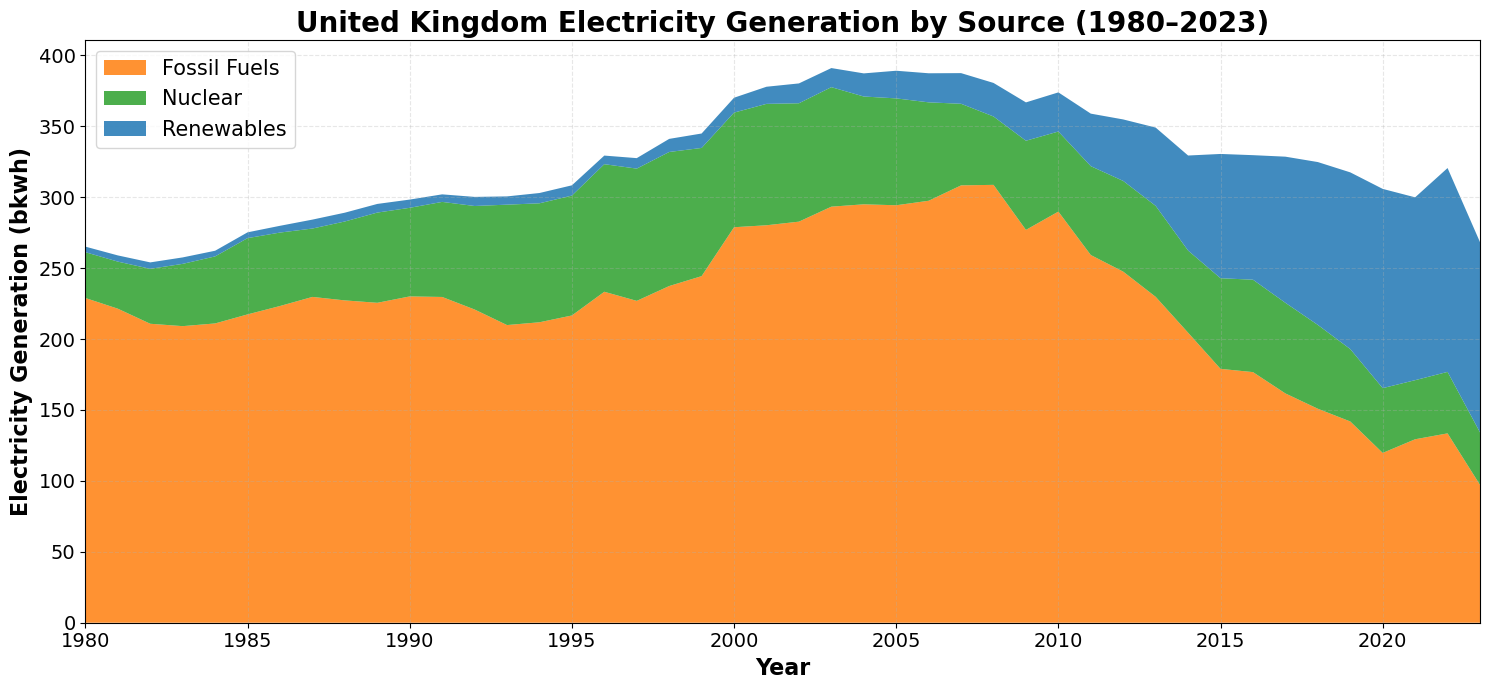

In [41]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 自动搜索文件
csv_files = glob.glob("**/*generation*bkwh.csv", recursive=True)
file_map = {os.path.basename(f): f for f in csv_files}

# 年份 1980–2023
years = np.arange(1980, 2024)
year_strs = years.astype(str)

# 读取沙特阿拉伯数据函数
def get_saudi(filename):
    df = pd.read_csv(file_map[filename], na_values=["NA", "N/A", "nan", ""])
    saudi = df[df["Country"].str.strip() == "United Kingdom"].iloc[0]
    return saudi[year_strs].fillna(0).astype(float).values

# 读取三大类数据
fossil = get_saudi("fossil-fuels-generation-bkwh.csv")
nuclear = get_saudi("nuclear-generation-bkwh.csv")
renewables = get_saudi("renewables-generation-bkwh.csv")

# ===================== 可调节参数（在这里改大小） =====================
TICK_FONT_SIZE = 14      # X/Y 轴刻度数字大小（修改这里）
LABEL_FONT_SIZE = 16     # X/Y 轴标签大小
TITLE_FONT_SIZE = 20     # 标题大小
LEGEND_FONT_SIZE = 15    # 图例大小

# ===================== 绘图（完全匹配你的风格） =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
fig, ax = plt.subplots(figsize=(15, 7))

# 堆叠面积图（专业配色 + 干净风格）
ax.stackplot(
    years,
    fossil,
    nuclear,
    renewables,
    labels=["Fossil Fuels", "Nuclear", "Renewables"],
    colors=["#ff7f0e", "#2ca02c", "#1f77b4"],
    alpha=0.85
)

# 轴标签
ax.set_xlabel('Year', fontsize=LABEL_FONT_SIZE, weight='bold')
ax.set_ylabel('Electricity Generation (bkwh)', fontsize=LABEL_FONT_SIZE, weight='bold')

# 标题
plt.title('United Kingdom Electricity Generation by Source (1980–2023)', fontsize=TITLE_FONT_SIZE, weight='bold')

# 坐标轴刻度 + 网格（关键：设置刻度数字大小）
ax.set_xticks(np.arange(1980, 2024, 5))
ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)  # 控制 X/Y 数字大小
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=LEGEND_FONT_SIZE)
ax.set_xlim(1980, 2023)
fig.tight_layout()
#plt.savefig('a.png', dpi=300, bbox_inches='tight')
plt.show()

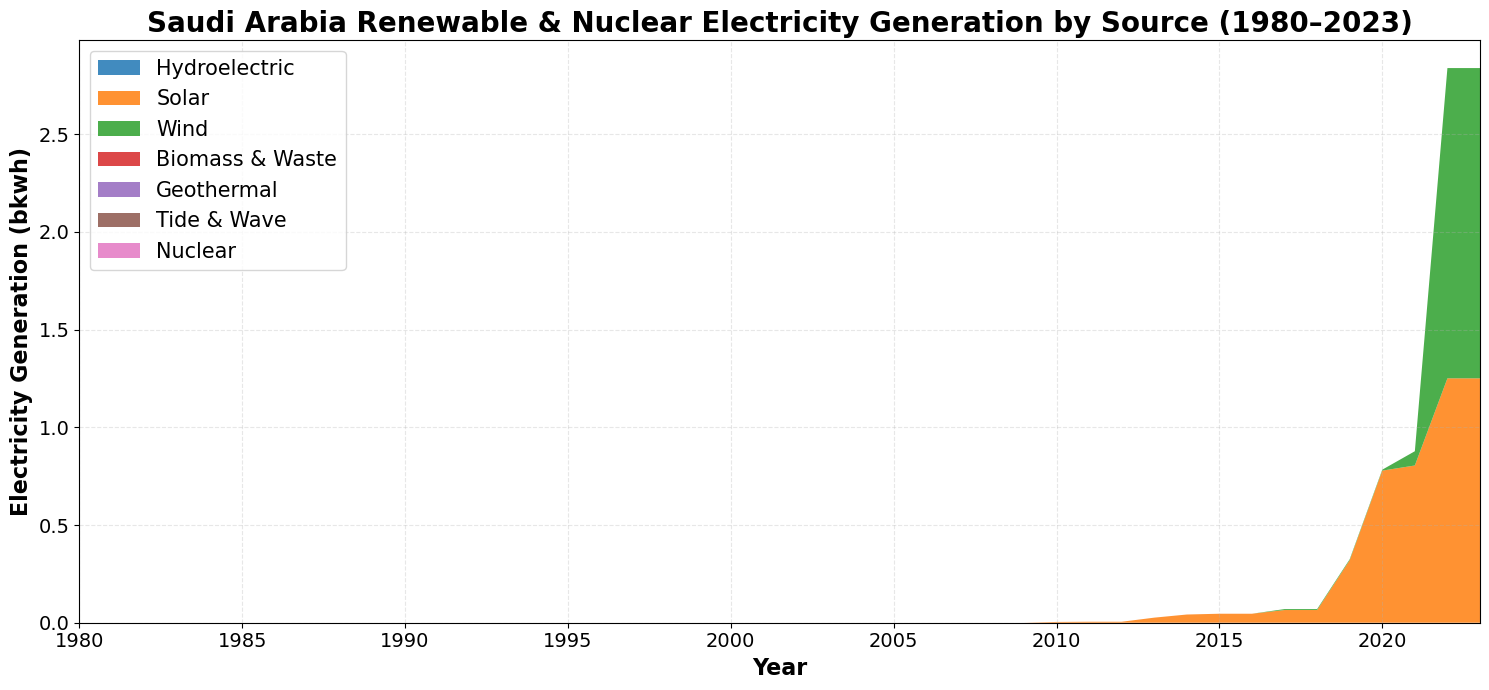

In [43]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 自动搜索文件
csv_files = glob.glob("**/*generation*bkwh.csv", recursive=True)
file_map = {os.path.basename(f): f for f in csv_files}

# 年份 1980–2023
years = np.arange(1980, 2024)
year_strs = years.astype(str)

# 读取沙特数据
def get_saudi(filename):
    df = pd.read_csv(file_map[filename], na_values=["NA", "N/A", "nan", ""])
    saudi = df[df["Country"].str.strip() == "Saudi Arabia"].iloc[0]
    return saudi[year_strs].fillna(0).astype(float).values

# 拆分出所有可再生能源细项
hydro         = get_saudi("hydroelectricity-generation-bkwh.csv")
solar         = get_saudi("solar-generation-bkwh.csv")
wind          = get_saudi("wind-generation-bkwh.csv")
biomass       = get_saudi("biomass-and-waste-generation-bkwh.csv")
geothermal    = get_saudi("geothermal-generation-bkwh.csv")
tide_wave     = get_saudi("tide-and-wave-generation-bkwh.csv")

# 核电
nuclear       = get_saudi("nuclear-generation-bkwh.csv")

# ===================== 统一字体大小参数（和上一版完全一致） =====================
TICK_FONT_SIZE = 14      # X/Y 轴刻度数字大小
LABEL_FONT_SIZE = 16     # X/Y 轴标签大小
TITLE_FONT_SIZE = 20     # 标题大小
LEGEND_FONT_SIZE = 15    # 图例大小

# ===================== 绘图（统一风格） =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
fig, ax = plt.subplots(figsize=(15, 7))

ax.stackplot(
    years,
    hydro,
    solar,
    wind,
    biomass,
    geothermal,
    tide_wave,
    nuclear,
    labels=[
        "Hydroelectric",
        "Solar",
        "Wind",
        "Biomass & Waste",
        "Geothermal",
        "Tide & Wave",
        "Nuclear",
    ],
    alpha=0.85
)

# 轴标签
ax.set_xlabel('Year', fontsize=LABEL_FONT_SIZE, weight='bold')
ax.set_ylabel('Electricity Generation (bkwh)', fontsize=LABEL_FONT_SIZE, weight='bold')

# 标题
plt.title('Saudi Arabia Renewable & Nuclear Electricity Generation by Source (1980–2023)', fontsize=TITLE_FONT_SIZE, weight='bold')

# 坐标轴刻度 + 网格（控制数字大小）
ax.set_xticks(np.arange(1980, 2024, 5))
ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(1980, 2023)
# 图例
ax.legend(loc='upper left', fontsize=LEGEND_FONT_SIZE)

fig.tight_layout()
#plt.savefig('a.png', dpi=300, bbox_inches='tight')
plt.show()